In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [ ]:
torch.manual_seed(42)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 35.9 MB


In [ ]:
df.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,6000.000000,6000.0,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,...,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.00000
mean,4.489667,0.0,0.003333,0.022833,0.095833,0.229667,0.380833,0.815000,2.040500,5.851500,...,34.411500,23.410833,16.781833,18.320167,23.820167,18.936833,9.157167,2.783833,0.903833,0.09300
std,2.840464,0.0,0.075210,0.457180,2.494464,4.855634,5.883755,8.964309,13.320114,24.088175,...,57.150747,48.769483,42.327168,44.743938,53.096607,46.870204,31.205610,17.486349,9.630180,2.54508
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,59.000000,8.250000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,0.0,3.000000,32.000000,146.000000,224.000000,213.000000,221.000000,221.000000,222.000000,...,255.000000,249.000000,255.000000,255.000000,254.000000,255.000000,248.000000,255.000000,192.000000,97.00000


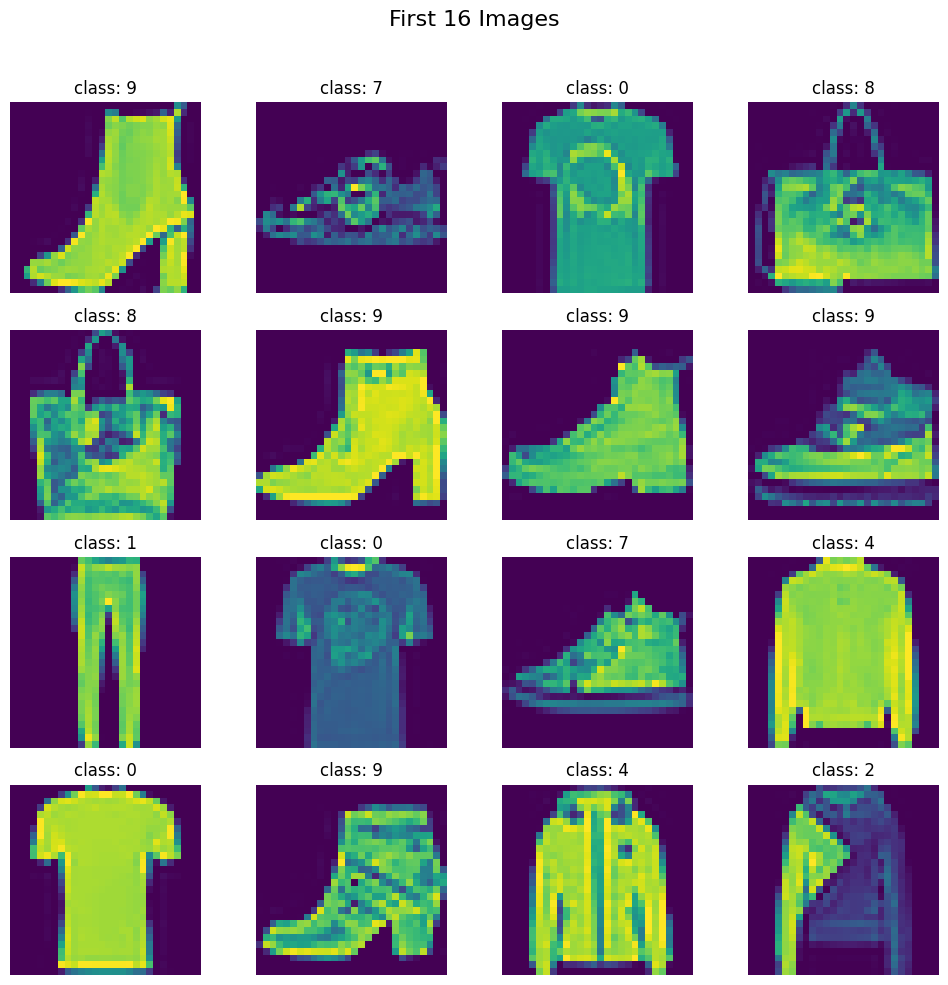

In [ ]:
fig, axes = plt.subplots(4, 4, figsize = (10, 10))
fig.suptitle('First 16 Images', fontsize = 16)
for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28, 28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'class: {df.iloc[i, 0]}')
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4800, 784)
(1200, 784)
(4800,)
(1200,)


In [ ]:
class CustomDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype = torch.float32).reshape(-1, 1, 28, 28)
    self.y = torch.tensor(y, dtype = torch.long)
  def __len__(self):
    return len(self.X)
  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [ ]:
train_Data = CustomDataset(X_train, y_train)
test_Data = CustomDataset(X_test, y_test)
train_Dataloader = DataLoader(train_Data, batch_size = 128, shuffle = True, pin_memory = True)
test_Dataloader = DataLoader(test_Data, batch_size = 128, shuffle = True, pin_memory = True)

In [ ]:
class CNNModel(nn.Module):
  def __init__(self, input_features):
    super().__init__()
    self.features = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size = 3, stride = 1, padding = 'same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size = 2, stride = 2),

        nn.Conv2d(32, 64, kernel_size = 3, padding = 'same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size = 2, stride = 2),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64 * 7 * 7, 128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)

    return x

In [ ]:
learning = 0.01
epochs = 100

In [ ]:
model = CNNModel(1)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = learning, weight_decay = 0.01)

In [ ]:
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_Dataloader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        y_pred = model(batch_features)
        loss = criterion(y_pred, batch_labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_epoch_loss += loss.item()
    total_epoch_loss /= len(train_Dataloader)
    print(f"Epoch {epoch + 1}, Loss: {total_epoch_loss}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1, Loss: 1.9921313147795827
Epoch 2, Loss: 1.3913871332218772
Epoch 3, Loss: 1.109726038418318
Epoch 4, Loss: 0.9579039388581326
Epoch 5, Loss: 0.865161618119792
Epoch 6, Loss: 0.8055900696076845
Epoch 7, Loss: 0.7456511588473069
Epoch 8, Loss: 0.6992518933195817
Epoch 9, Loss: 0.6831447905615756
Epoch 10, Loss: 0.6401752798180831
Epoch 11, Loss: 0.614816206066232
Epoch 12, Loss: 0.5949904181455311
Epoch 13, Loss: 0.5700594884784598
Epoch 14, Loss: 0.5525515989253396
Epoch 15, Loss: 0.5427837873760023
Epoch 16, Loss: 0.5096233157735122
Epoch 17, Loss: 0.5085290042977584
Epoch 18, Loss: 0.4871357404871991
Epoch 19, Loss: 0.46389469112220566
Epoch 20, Loss: 0.4478586935683301
Epoch 21, Loss: 0.43543984231195954
Epoch 22, Loss: 0.4249400041605297
Epoch 23, Loss: 0.41402233352786616
Epoch 24, Loss: 0.4073477544282612
Epoch 25, Loss: 0.3971163724598132
Epoch 26, Loss: 0.379298683059843
Epoch 27, Loss: 0.3633792572899869
Epoch 28, Loss: 0.3590925853503378
Epoch 29, Loss: 0.350350703848

In [ ]:
model.eval()

CNNModel(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in test_Dataloader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    y_pred = model(batch_features)
    _, predicted = torch.max(y_pred, 1)
    total += batch_labels.size(0) # shape[0] will also work the same.
    correct += (predicted == batch_labels).sum().item()
accuracy = correct / total
print(accuracy)

0.8758333333333334


In [ ]:
with torch.no_grad():
  for batch_features, batch_labels in train_Dataloader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    y_pred = model(batch_features)
    _, predicted = torch.max(y_pred, 1)
    total += batch_labels.size(0) # shape[0] will also work the same.
    correct += (predicted == batch_labels).sum().item()
accuracy = correct / total
print(accuracy)

0.9746666666666667
